In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("data/cement_slump.csv")

In [3]:
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Cement                              103 non-null    float64
 1   Slag                                103 non-null    float64
 2   Fly ash                             103 non-null    float64
 3   Water                               103 non-null    float64
 4   SP                                  103 non-null    float64
 5   Coarse Aggr.                        103 non-null    float64
 6   Fine Aggr.                          103 non-null    float64
 7   SLUMP(cm)                           103 non-null    float64
 8   FLOW(cm)                            103 non-null    float64
 9   Compressive Strength (28-day)(Mpa)  103 non-null    float64
dtypes: float64(10)
memory usage: 8.2 KB


<Axes: xlabel='Water', ylabel='Compressive Strength (28-day)(Mpa)'>

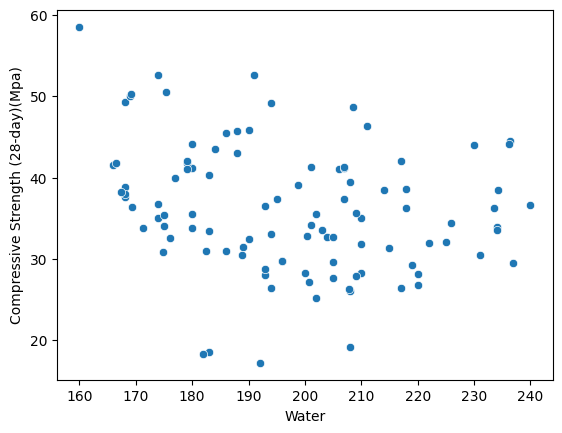

In [5]:
sns.scatterplot(x=df["Water"], y=df["Compressive Strength (28-day)(Mpa)"])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x = df["Water"]
y = df["Compressive Strength (28-day)(Mpa)"]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=325)

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train.to_frame())

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
l1 = LinearRegression()
l1.fit(scaled_x_train, y_train)

LinearRegression()

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
y_train.shape

(92,)

In [15]:
y_pred = l1.predict(y_train.to_frame())

c:\Users\navee\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

In [17]:
threshold = y_train.median()
y_binary = (y_train > threshold).astype(int)
pred_threshold = np.median(y_pred)
pred_binary = (y_pred > pred_threshold).astype(int)
score = accuracy_score(y_binary, pred_binary)

In [18]:
print(score)

0.0


In [19]:
r2 = r2_score(y_binary, pred_binary)

In [20]:
r2

-3.0